# Interest rate swaps

Build a fixed-for-floating swap from its two legs and freeze it before hedging.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A payer interest rate swap exchanges fixed payments for floating receipts. The fair fixed coupon sets their initial present values equal; it is a property of the schedule, projection and discounting assumptions together.

Writing the fixed annuity as $A=\sum_i\alpha_iD_i$ and the projected floating value per unit notional as $B$, the fair rate is $K^*=B/A$. A swap with a frozen coupon $K$ has $PV=N(B-KA)$ from the payer's perspective.

The case starts one business day after 15 September 2026, lasts seven years, pays fixed annually and receives a synthetic USD 3M rate quarterly. It uses Actual/360, Modified Following and separate term projection/OIS discount curves. The next-business-day start avoids a hidden requirement for historical index fixings.

The notebook reconstructs each leg from indexed-coupon dates, computes the fair rate independently and compares the total PV with QuantLib. It then raises the fixed coupon by 10 bp and checks the analytical annuity effect. This holds the forecast curve and floating leg fixed, separating a contractual coupon change from a market-curve shock.

There is no principal exchange in this single-currency IRS. The seven-year payer becomes the hedge instrument in the connected bond study. When scenarios move curves, its coupon and hedge units stay frozen; recalculating a fair coupon after each shock would replace the original contract and erase the risk being studied.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from research.pricing import swap
with valuation_date():
    discount,projection,_=curves()
    instrument,flows,rate=swap(discount,projection)
    fixed=flows.query('instrument=="fixed"')
    floating=flows.query('instrument=="float"')
    annuity=np.sum(fixed.accrual*fixed.discount)
    independent_rate=floating.pv.sum()/(100*annuity)
    assert abs(independent_rate-rate)<1e-10
    assert abs(flows.pv.sum()-instrument.NPV())<1e-8
    offmarket,_,_=swap(discount,projection,rate+.001)
    assert abs(offmarket.NPV()+100*.001*annuity)<1e-8
    summary=pd.DataFrame([{'fair_fixed_rate_pct':100*rate,'fixed_annuity':annuity,'par_swap_PV':instrument.NPV(),'PV_after_fixed_coupon_plus10bp':offmarket.NPV()}])
display(summary.round(6));display(flows.round(6))

,fair_fixed_rate_pct,fixed_annuity,par_swap_PV,PV_after_fixed_coupon_plus10bp
0,3.959824,6.185755,-0.0,-0.618575


,instrument,date,accrual,amount,discount,pv
0,fixed,2027-09-16,1.013889,-4.014822,0.962807,-3.865499
1,fixed,2028-09-18,1.022222,-4.047820,0.928676,-3.759115
2,fixed,2029-09-17,1.011111,-4.003822,0.897902,-3.595040
3,fixed,2030-09-16,1.011111,-4.003822,0.868158,-3.475950
4,fixed,2031-09-16,1.013889,-4.014822,0.840201,-3.373258
5,fixed,2032-09-16,1.016667,-4.025821,0.812373,-3.270468
6,fixed,2033-09-16,1.013889,-4.014822,0.785881,-3.155171
7,float,2026-12-16,0.252778,1.071568,0.990517,1.061406
8,float,2027-03-16,0.250000,1.059731,0.981326,1.039942
9,float,2027-06-16,0.255556,1.083408,0.972020,1.053094


## Economic relationship

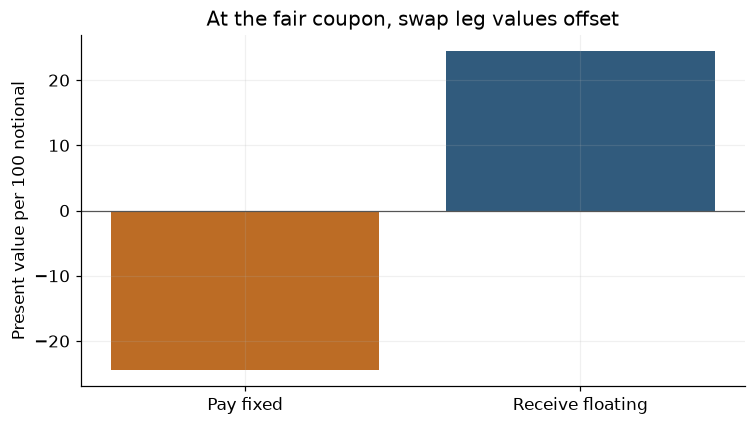

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
leg_pv=flows.groupby('instrument').pv.sum().reindex(['fixed','float'])
ax.bar(['Pay fixed','Receive floating'],leg_pv,color=['#bc6c25','#315b7d'])
ax.axhline(0,color='#555555',lw=.8)
ax.set(ylabel='Present value per 100 notional',title='At the fair coupon, swap leg values offset')
fig.tight_layout();plt.show()

## Interpretation

Independent floating cash flows and the fixed annuity reproduce the fair coupon. Paying an additional 10 bp reduces PV by exactly notional times the annuity times 0.001 under unchanged curves.